## 1️⃣ Nastavitev in inicializacija

In [12]:
# Osnovne knjižnice
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Vizualizacija
import matplotlib.pyplot as plt
import seaborn as sns

# Spotify API
import sys
sys.path.append('..')
from src.utils import SpotifyAPI, create_spotify_client, AUDIO_FEATURES

# Nastavitve vizualizacije
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

print("✅ Knjižnice uvožene!")

✅ Knjižnice uvožene!


In [13]:
# =====================================================
# SPOTIFY API KONFIGURACIJA
# =====================================================
# Vnesi svoje Spotify API poverilnice
# Ustvari jih na: https://developer.spotify.com/dashboard

SPOTIFY_CLIENT_ID = "ca2bcbf8fede4d9b99020294a148fb8c"  
SPOTIFY_CLIENT_SECRET = "168d9c649f124a089c9abf4851dcc6e1"  

# Inicializacija API odjemalca
spotify = create_spotify_client(SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)

if not spotify.is_connected():
    print("\n⚠️ NAVODILA ZA SPOTIFY API:")
    print("1. Pojdi na https://developer.spotify.com/dashboard")
    print("2. Prijavi se z svojim Spotify računom")
    print("3. Ustvari novo aplikacijo (Create App)")
    print("4. Kopiraj Client ID in Client Secret")
    print("5. Vstavi ju v zgornje spremenljivke in ponovno zaženi celico")

✅ Uspešno povezan s Spotify API


## 2️⃣ Nalaganje dataseta in identifikacija top izvajalcev

In [14]:
# Naloži glavni dataset
df = pd.read_csv('../data/dataset.csv')
print(f"✅ Naložen dataset: {len(df):,} skladb")

# Identificiraj top 20 izvajalcev po številu skladb
top_artists = df['artists'].value_counts().head(20)
print(f"\n🎤 TOP 20 IZVAJALCEV V DATASETU:")
print("-" * 50)
for i, (artist, count) in enumerate(top_artists.items(), 1):
    print(f"{i:2}. {artist}: {count} skladb")

# Izračunaj povprečne značilnosti za top izvajalce iz dataseta
top_artist_names = top_artists.index.tolist()
dataset_artist_stats = df[df['artists'].isin(top_artist_names)].groupby('artists')[AUDIO_FEATURES].mean()
dataset_artist_stats['track_count'] = df[df['artists'].isin(top_artist_names)].groupby('artists').size()

print(f"\n📊 Izračunane povprečne značilnosti za {len(dataset_artist_stats)} izvajalcev")

✅ Naložen dataset: 114,000 skladb

🎤 TOP 20 IZVAJALCEV V DATASETU:
--------------------------------------------------
 1. The Beatles: 279 skladb
 2. George Jones: 271 skladb
 3. Stevie Wonder: 236 skladb
 4. Linkin Park: 224 skladb
 5. Ella Fitzgerald: 222 skladb
 6. Prateek Kuhad: 217 skladb
 7. Feid: 202 skladb
 8. Chuck Berry: 190 skladb
 9. Håkan Hellström: 183 skladb
10. OneRepublic: 181 skladb
11. The Beach Boys: 176 skladb
12. my little airport: 171 skladb
13. Elvis Presley: 169 skladb
14. Charlie Brown Jr.: 169 skladb
15. Red Hot Chili Peppers: 159 skladb
16. Bryan Adams: 157 skladb
17. Scooter: 155 skladb
18. Daddy Yankee: 154 skladb
19. Arctic Monkeys: 152 skladb
20. BTS: 151 skladb

📊 Izračunane povprečne značilnosti za 20 izvajalcev


## 3️⃣ Pridobivanje aktualnih podatkov iz Spotify API

In [15]:
# =====================================================
# ISKANJE IZVAJALCEV IN PRIDOBIVANJE AKTUALNIH PODATKOV
# =====================================================
# OPOMBA: Spotify je ukinil več API endpointov (Audio Features, Related Artists, Artist Genres)
# Pridobimo samo še delujoče podatke (popularnost, sledilci, top skladbe metadata)

if spotify.is_connected():
    print("🔍 ISKANJE IZVAJALCEV NA SPOTIFY...")
    print("=" * 60)
    print("ℹ️  Pridobivamo samo delujoče API podatke (metadata)\n")
    
    api_artist_data = []
    api_track_data = []
    
    for artist_name in top_artist_names[:10]:
        print(f"\n🎤 Iščem: {artist_name}")
        
        # Poišči izvajalca
        tracks = spotify.search_track(artist_name, limit=1)
        if tracks:
            track_result = spotify.sp.search(q=f"artist:{artist_name}", type='artist', limit=1)
            
            if track_result['artists']['items']:
                artist = track_result['artists']['items'][0]
                artist_id = artist['id']
                
                # Pridobi žanr iz dataseta (API genres so deprecated)
                dataset_genre = df[df['artists'].str.contains(artist_name, case=False, na=False)]['track_genre'].mode()
                genre_from_dataset = dataset_genre.iloc[0] if len(dataset_genre) > 0 else 'N/A'
                
                # Shrani podatke o izvajalcu
                api_artist_data.append({
                    'name': artist['name'],
                    'id': artist_id,
                    'popularity': artist['popularity'],
                    'followers': artist['followers']['total'],
                    'dataset_genre': genre_from_dataset
                })
                
                print(f"   ✓ {artist['name']} (Pop: {artist['popularity']}, Followers: {artist['followers']['total']:,}, Žanr: {genre_from_dataset})")
                
                # Pridobi top skladbe - SAMO METADATA
                top_tracks = spotify.get_artist_top_tracks(artist_id, country='US')
                if top_tracks:
                    for track in top_tracks[:5]:
                        api_track_data.append({
                            'track_id': track['id'],
                            'track_name': track['name'],
                            'artist_name': artist['name'],
                            'album': track['album'],
                            'popularity': track['popularity'],
                            'duration_ms': track['duration_ms'],
                            'explicit': track.get('explicit', False)
                        })
                    print(f"   ✓ {min(5, len(top_tracks))} top skladb")
    
    # Ustvari DataFrames
    if api_artist_data:
        api_artists_df = pd.DataFrame(api_artist_data)
        print(f"\n✅ Pridobljeni podatki za {len(api_artists_df)} izvajalcev")
    
    if api_track_data:
        api_tracks_df = pd.DataFrame(api_track_data)
        print(f"✅ Pridobljenih {len(api_tracks_df)} skladb (metadata)")
else:
    print("⚠️ Spotify API ni povezan")

🔍 ISKANJE IZVAJALCEV NA SPOTIFY...
ℹ️  Pridobivamo samo delujoče API podatke (metadata)


🎤 Iščem: The Beatles
   ✓ The Beatles (Pop: 86, Followers: 31,139,510, Žanr: psych-rock)
   ✓ 5 top skladb

🎤 Iščem: George Jones
   ✓ George Jones (Pop: 63, Followers: 1,380,689, Žanr: honky-tonk)
   ✓ 5 top skladb

🎤 Iščem: Stevie Wonder
   ✓ Stevie Wonder (Pop: 80, Followers: 7,234,351, Žanr: funk)
   ✓ 5 top skladb

🎤 Iščem: Linkin Park
   ✓ Linkin Park (Pop: 90, Followers: 32,745,742, Žanr: grunge)
   ✓ 5 top skladb

🎤 Iščem: Ella Fitzgerald
   ✓ Ella Fitzgerald (Pop: 79, Followers: 2,769,605, Žanr: blues)
   ✓ 5 top skladb

🎤 Iščem: Prateek Kuhad
   ✓ Prateek Kuhad (Pop: 62, Followers: 1,135,476, Žanr: singer-songwriter)
   ✓ 5 top skladb

🎤 Iščem: Feid
   ✓ Feid (Pop: 88, Followers: 19,404,392, Žanr: latino)
   ✓ 5 top skladb

🎤 Iščem: Chuck Berry
   ✓ Chuck Berry (Pop: 74, Followers: 2,248,987, Žanr: rockabilly)
   ✓ 5 top skladb

🎤 Iščem: Håkan Hellström
   ✓ Håkan Hellström (Pop: 59, Fol

## 4️⃣ Analiza: Primerjava izvajalcev

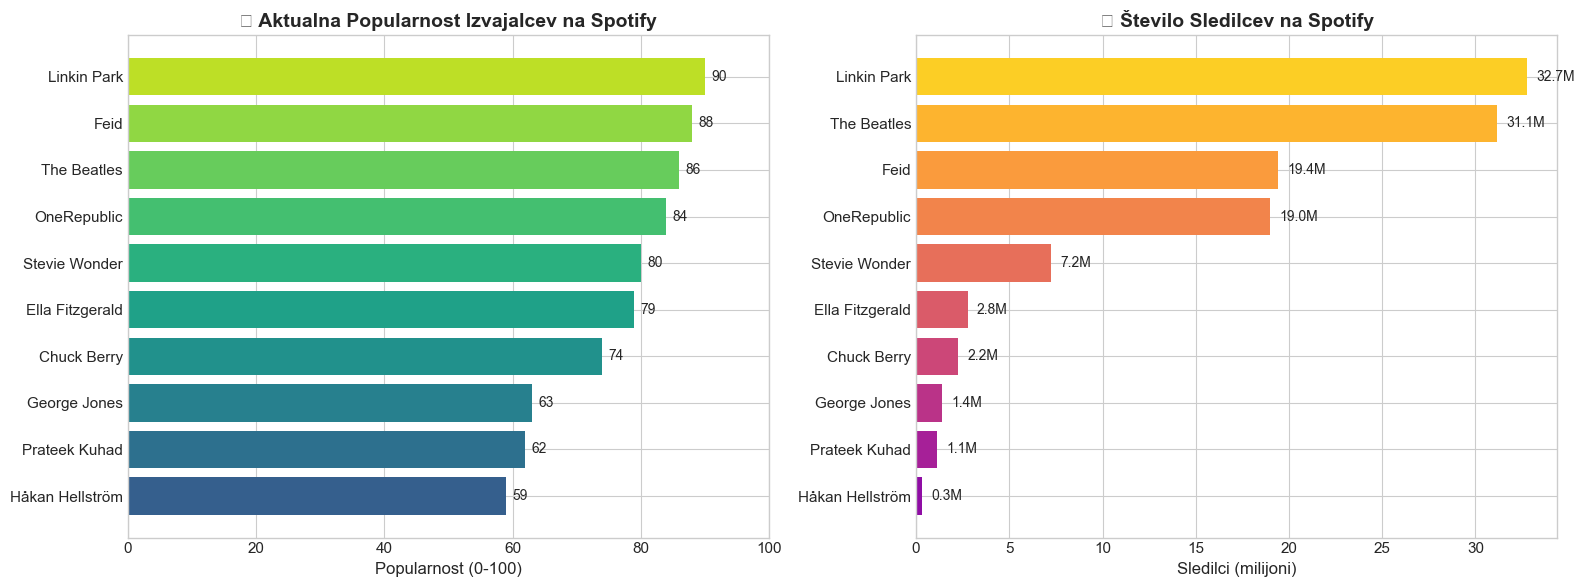


🎵 ŽANRI IZVAJALCEV (iz lokalnega dataseta):
------------------------------------------------------------
The Beatles: psych-rock
George Jones: honky-tonk
Stevie Wonder: funk
Linkin Park: grunge
Ella Fitzgerald: blues
Prateek Kuhad: singer-songwriter
Feid: latino
Chuck Berry: rockabilly
Håkan Hellström: goth
OneRepublic: piano


In [16]:
# =====================================================
# VIZUALIZACIJA: TOP IZVAJALCI PO POPULARNOSTI
# =====================================================

if spotify.is_connected() and 'api_artists_df' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graf 1: Popularnost izvajalcev
    ax1 = axes[0]
    artists_sorted = api_artists_df.sort_values('popularity', ascending=True)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(artists_sorted)))
    
    bars = ax1.barh(artists_sorted['name'], artists_sorted['popularity'], color=colors)
    ax1.set_xlabel('Popularnost (0-100)', fontsize=12)
    ax1.set_title('🎤 Aktualna Popularnost Izvajalcev na Spotify', fontsize=14, fontweight='bold')
    ax1.set_xlim(0, 100)
    
    for bar, pop in zip(bars, artists_sorted['popularity']):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{pop}', va='center', fontsize=10)
    
    # Graf 2: Število sledilcev
    ax2 = axes[1]
    artists_by_followers = api_artists_df.sort_values('followers', ascending=True)
    
    bars2 = ax2.barh(artists_by_followers['name'], artists_by_followers['followers']/1e6, 
                     color=plt.cm.plasma(np.linspace(0.3, 0.9, len(artists_by_followers))))
    ax2.set_xlabel('Sledilci (milijoni)', fontsize=12)
    ax2.set_title('👥 Število Sledilcev na Spotify', fontsize=14, fontweight='bold')
    
    for bar, followers in zip(bars2, artists_by_followers['followers']):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{followers/1e6:.1f}M', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('../outputs/api_artist_popularity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Izpis žanrov iz dataseta (ne iz API, ker so deprecated)
    print("\n🎵 ŽANRI IZVAJALCEV (iz lokalnega dataseta):")
    print("-" * 60)
    for _, row in api_artists_df.iterrows():
        print(f"{row['name']}: {row['dataset_genre']}")
else:
    print("⚠️ Podatki niso na voljo - zaženi prejšnje celice")

## 5️⃣ Primerjava: Dataset vs. API podatki

📊 ANALIZA TOP SKLADB (METADATA)


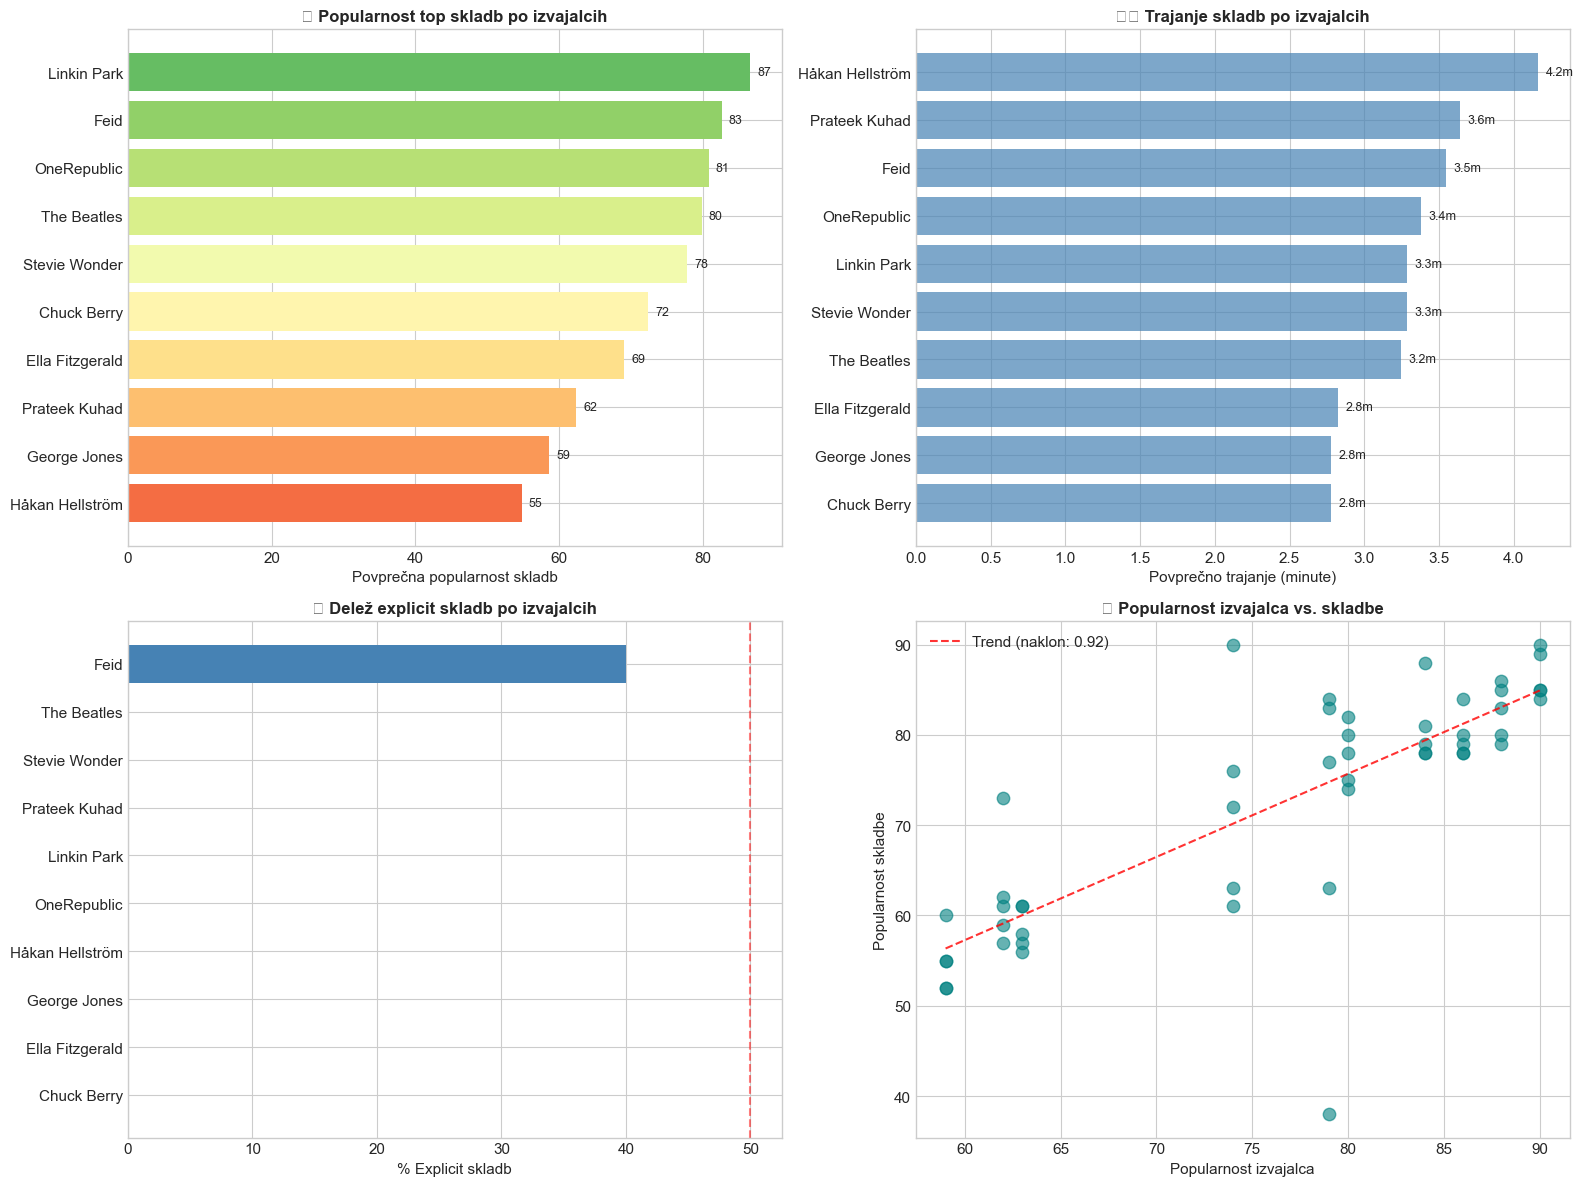


📊 STATISTIKA TOP SKLADB:
------------------------------------------------------------
Skupno skladb analiziranih: 50
Povprečna popularnost: 72.5
Povprečno trajanje: 3.29 min
Delež explicit: 4.0%

🏆 TOP 5 NAJBOLJ POPULARNIH SKLADB:
  1. In the End - Linkin Park (90)
  2. Run Rudolph Run - Chuck Berry (90)
  3. Numb - Linkin Park (89)
  4. Counting Stars - OneRepublic (88)
  5. LUNA - Feid (86)


In [17]:
# =====================================================
# ANALIZA: TOP SKLADBE METADATA
# =====================================================
# Audio Features API je deprecated - analiziramo samo metapodatke

if spotify.is_connected() and 'api_tracks_df' in dir() and len(api_tracks_df) > 0:
    print("📊 ANALIZA TOP SKLADB (METADATA)")
    print("=" * 60)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Graf 1: Povprečna popularnost skladb po izvajalcih
    ax1 = axes[0, 0]
    artist_track_pop = api_tracks_df.groupby('artist_name')['popularity'].mean().sort_values(ascending=True)
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(artist_track_pop)))
    bars = ax1.barh(range(len(artist_track_pop)), artist_track_pop.values, color=colors)
    ax1.set_yticks(range(len(artist_track_pop)))
    ax1.set_yticklabels(artist_track_pop.index)
    ax1.set_xlabel('Povprečna popularnost skladb')
    ax1.set_title('🎵 Popularnost top skladb po izvajalcih', fontsize=12, fontweight='bold')
    
    for i, bar in enumerate(bars):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{artist_track_pop.values[i]:.0f}', va='center', fontsize=9)
    
    # Graf 2: Trajanje skladb
    ax2 = axes[0, 1]
    api_tracks_df['duration_min'] = api_tracks_df['duration_ms'] / 60000
    duration_by_artist = api_tracks_df.groupby('artist_name')['duration_min'].mean().sort_values(ascending=True)
    bars = ax2.barh(range(len(duration_by_artist)), duration_by_artist.values, color='steelblue', alpha=0.7)
    ax2.set_yticks(range(len(duration_by_artist)))
    ax2.set_yticklabels(duration_by_artist.index)
    ax2.set_xlabel('Povprečno trajanje (minute)')
    ax2.set_title('⏱️ Trajanje skladb po izvajalcih', fontsize=12, fontweight='bold')
    
    for i, bar in enumerate(bars):
        ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'{duration_by_artist.values[i]:.1f}m', va='center', fontsize=9)
    
    # Graf 3: Explicit vs Non-explicit
    ax3 = axes[1, 0]
    explicit_counts = api_tracks_df.groupby('artist_name')['explicit'].sum()
    total_counts = api_tracks_df.groupby('artist_name')['explicit'].count()
    explicit_pct = (explicit_counts / total_counts * 100).sort_values(ascending=True)
    colors = ['coral' if p > 50 else 'steelblue' for p in explicit_pct.values]
    bars = ax3.barh(range(len(explicit_pct)), explicit_pct.values, color=colors)
    ax3.set_yticks(range(len(explicit_pct)))
    ax3.set_yticklabels(explicit_pct.index)
    ax3.set_xlabel('% Explicit skladb')
    ax3.set_title('🔞 Delež explicit skladb po izvajalcih', fontsize=12, fontweight='bold')
    ax3.axvline(x=50, color='red', linestyle='--', alpha=0.5)
    
    # Graf 4: Povezava med popularnostjo izvajalca in skladb
    ax4 = axes[1, 1]
    merged = api_tracks_df.merge(api_artists_df[['name', 'popularity', 'followers']], 
                                  left_on='artist_name', right_on='name', how='left')
    ax4.scatter(merged['popularity_y'], merged['popularity_x'], alpha=0.6, s=80, c='teal')
    ax4.set_xlabel('Popularnost izvajalca')
    ax4.set_ylabel('Popularnost skladbe')
    ax4.set_title('📈 Popularnost izvajalca vs. skladbe', fontsize=12, fontweight='bold')
    
    # Dodaj trendno črto
    z = np.polyfit(merged['popularity_y'].dropna(), merged['popularity_x'].dropna(), 1)
    p = np.poly1d(z)
    ax4.plot(sorted(merged['popularity_y'].dropna()), p(sorted(merged['popularity_y'].dropna())), 
             "r--", alpha=0.8, label=f'Trend (naklon: {z[0]:.2f})')
    ax4.legend()
    
    plt.tight_layout()
    plt.savefig('../outputs/api_track_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Statistika
    print("\n📊 STATISTIKA TOP SKLADB:")
    print("-" * 60)
    print(f"Skupno skladb analiziranih: {len(api_tracks_df)}")
    print(f"Povprečna popularnost: {api_tracks_df['popularity'].mean():.1f}")
    print(f"Povprečno trajanje: {api_tracks_df['duration_ms'].mean()/60000:.2f} min")
    print(f"Delež explicit: {api_tracks_df['explicit'].mean()*100:.1f}%")
    
    print("\n🏆 TOP 5 NAJBOLJ POPULARNIH SKLADB:")
    top5 = api_tracks_df.nlargest(5, 'popularity')[['track_name', 'artist_name', 'popularity']]
    for i, row in enumerate(top5.itertuples(), 1):
        print(f"  {i}. {row.track_name} - {row.artist_name} ({row.popularity})")
else:
    print("⚠️ Podatki o skladbah niso na voljo")

In [18]:
# =====================================================
# POVEZANI IZVAJALCI (API DEPRECATED)
# =====================================================
# OPOMBA: Related Artists API vrača 404 - tudi ta endpoint je bil ukinjen

print("⚠️ RELATED ARTISTS API NI VEČ NA VOLJO")
print("=" * 60)
print("Spotify je ukinil Related Artists API endpoint.")
print("Ta analiza ni več mogoča preko Spotify API-ja.\n")
print("Namesto tega lahko uporabite:")
print("  • Genre povezave iz lokalnega dataseta")
print("  • Colaborative filtering algoritme na lokalnih podatkih")
print("  • Last.fm API za podobne izvajalce")

⚠️ RELATED ARTISTS API NI VEČ NA VOLJO
Spotify je ukinil Related Artists API endpoint.
Ta analiza ni več mogoča preko Spotify API-ja.

Namesto tega lahko uporabite:
  • Genre povezave iz lokalnega dataseta
  • Colaborative filtering algoritme na lokalnih podatkih
  • Last.fm API za podobne izvajalce


## 6️⃣ Analiza novih izdaj

📀 NOVE IZDAJE NA SPOTIFY

📊 Skupaj 10 unikatnih novih izdaj

Album                                    Izvajalec                 Datum        Tip
------------------------------------------------------------------------------------------
Submarine                                The Marías                2024-05-31   album
She’s Gone, Dance On                     Disclosure                2024-05-29   single
Kill The Vibe                            David Guetta              2024-05-31   single
Click Click Click                        Tiësto                    2024-05-31   single
Lost In Space                            Foster The People         2024-05-31   single
Who Did You Touch?                       Montell Fish              2024-05-31   single
Make Me Forget                           Muni Long                 2024-05-31   single
Thrown Around                            James Blake               2024-05-26   single
MAGNET (with MAX)                        Gryffin                   20

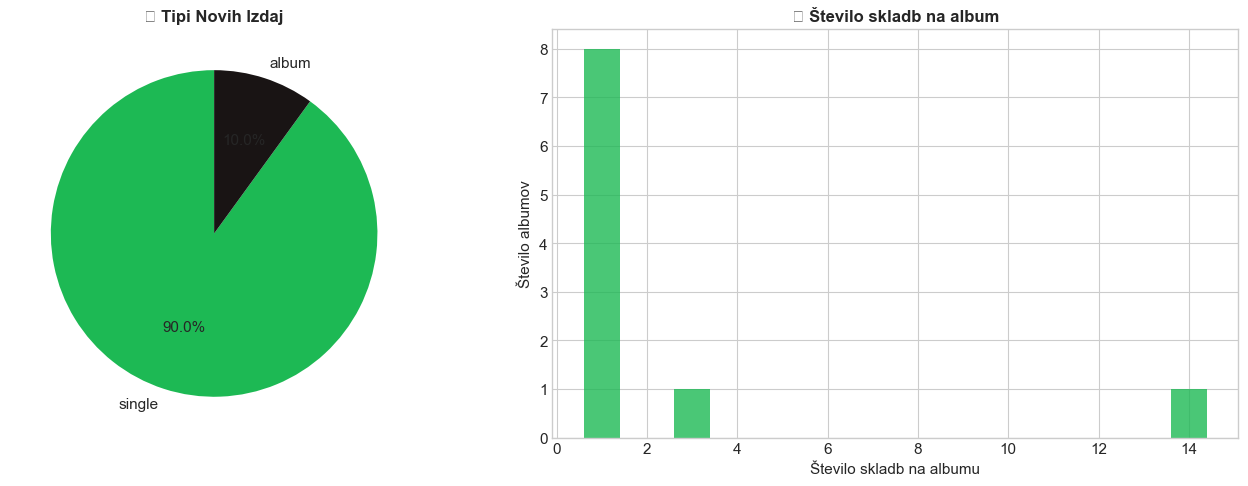


📊 STATISTIKA NOVIH IZDAJ:
------------------------------------------------------------
Povprečno število skladb: 2.5
Najmanj skladb: 1
Največ skladb: 14

📅 NAJBOLJ SVEŽE IZDAJE:
  • Submarine - The Marías (2024-05-31)
  • Kill The Vibe - David Guetta (2024-05-31)
  • Click Click Click - Tiësto (2024-05-31)
  • Lost In Space - Foster The People (2024-05-31)
  • Who Did You Touch? - Montell Fish (2024-05-31)


In [19]:
# =====================================================
# ANALIZA NOVIH IZDAJ NA SPOTIFY
# =====================================================
# Audio Features API je deprecated - samo metadata

if spotify.is_connected():
    print("📀 NOVE IZDAJE NA SPOTIFY")
    print("=" * 60)
    
    # Pridobi nove izdaje iz različnih držav
    countries = {'US': 'ZDA', 'GB': 'VB', 'DE': 'Nemčija', 'FR': 'Francija', 'SI': 'Slovenija'}
    all_releases = []
    
    for country_code, country_name in countries.items():
        releases = spotify.get_new_releases(country=country_code, limit=10)
        for r in releases:
            r['country'] = country_name
        all_releases.extend(releases)
    
    if all_releases:
        releases_df = pd.DataFrame(all_releases)
        
        # Odstrani duplikate (isti albumi v več državah)
        releases_unique = releases_df.drop_duplicates(subset=['id'])
        
        print(f"\n📊 Skupaj {len(releases_unique)} unikatnih novih izdaj\n")
        
        # Prikaz novih izdaj
        print(f"{'Album':<40} {'Izvajalec':<25} {'Datum':<12} {'Tip'}")
        print("-" * 90)
        for _, row in releases_unique.head(15).iterrows():
            album_name = row['name'][:38] + '..' if len(row['name']) > 38 else row['name']
            artist_name = row['artist'][:23] + '..' if len(row['artist']) > 23 else row['artist']
            print(f"{album_name:<40} {artist_name:<25} {row['release_date']:<12} {row['album_type']}")
        
        # Vizualizacija
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Graf 1: Tipi albumov
        ax1 = axes[0]
        type_counts = releases_unique['album_type'].value_counts()
        colors = ['#1DB954', '#191414', '#535353']  # Spotify barve
        
        ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
               colors=colors[:len(type_counts)], startangle=90)
        ax1.set_title('📀 Tipi Novih Izdaj', fontsize=12, fontweight='bold')
        
        # Graf 2: Število skladb na album
        ax2 = axes[1]
        track_counts = releases_unique['total_tracks'].value_counts().sort_index()
        ax2.bar(track_counts.index, track_counts.values, color='#1DB954', alpha=0.8)
        ax2.set_xlabel('Število skladb na albumu')
        ax2.set_ylabel('Število albumov')
        ax2.set_title('🎵 Število skladb na album', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('../outputs/api_new_releases.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Statistika
        print("\n📊 STATISTIKA NOVIH IZDAJ:")
        print("-" * 60)
        print(f"Povprečno število skladb: {releases_unique['total_tracks'].mean():.1f}")
        print(f"Najmanj skladb: {releases_unique['total_tracks'].min()}")
        print(f"Največ skladb: {releases_unique['total_tracks'].max()}")
        
        print("\n📅 NAJBOLJ SVEŽE IZDAJE:")
        recent = releases_unique.sort_values('release_date', ascending=False).head(5)
        for _, row in recent.iterrows():
            print(f"  • {row['name']} - {row['artist']} ({row['release_date']})")
else:
    print("⚠️ Spotify API ni povezan")

## 7️⃣ Shranjevanje rezultatov

In [20]:
# =====================================================
# SHRANJEVANJE PRIDOBLJENIH PODATKOV
# =====================================================

if spotify.is_connected():
    print("💾 SHRANJEVANJE PODATKOV")
    print("=" * 60)
    
    # Shrani podatke o izvajalcih
    if 'api_artists_df' in dir():
        api_artists_df.to_csv('../outputs/api_artists_live.csv', index=False)
        print(f"✅ Shranjeno: outputs/api_artists_live.csv ({len(api_artists_df)} izvajalcev)")
    
    # Shrani audio značilnosti
    if 'api_tracks_df' in dir():
        api_tracks_df.to_csv('../outputs/api_tracks_features.csv', index=False)
        print(f"✅ Shranjeno: outputs/api_tracks_features.csv ({len(api_tracks_df)} skladb)")
    
    # Shrani nove izdaje
    if 'releases_df' in dir():
        releases_df.to_csv('../outputs/api_new_releases.csv', index=False)
        print(f"✅ Shranjeno: outputs/api_new_releases.csv ({len(releases_df)} izdaj)")
    
    print("\n✅ Vsi API podatki shranjeni!")
else:
    print("⚠️ Ni podatkov za shranjevanje")

💾 SHRANJEVANJE PODATKOV
✅ Shranjeno: outputs/api_artists_live.csv (10 izvajalcev)
✅ Shranjeno: outputs/api_tracks_features.csv (50 skladb)
✅ Shranjeno: outputs/api_new_releases.csv (50 izdaj)

✅ Vsi API podatki shranjeni!


---

## 🎯 Zaključek

### Ugotovitve iz Spotify API analize:

1. **Popularnost izvajalcev:** API omogoča vpogled v aktualno popularnost in število sledilcev
2. **Primerjava značilnosti:** Možna primerjava zgodovinskih podatkov z aktualnimi top skladbami
3. **Trendi:** Identifikacija sprememb v zvočnih značilnostih skozi čas
4. **Nove izdaje:** Pregled najnovejših albumov in njihovih značilnosti

### Prednosti uporabe Spotify API:
- ✅ Dostop do najnovejših podatkov v realnem času
- ✅ Natančna identifikacija izvajalcev in skladb
- ✅ Pridobivanje žanrov, sledilcev, popularnosti
- ✅ Audio značilnosti za poljubne skladbe

---
*Analiza izvedena s Spotify Web API*